# Make Figures for GPS

Claire Punturieri  
September 5, 2026

In [ ]:

library(tidyverse)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

── Attaching packages ────────────────────────────────────── tidymodels 1.5.0 ──
✔ broom        1.0.13     ✔ rsample      1.3.2 
✔ dials        1.4.4      ✔ tailor       0.1.0 
✔ infer        1.1.0      ✔ tune         2.1.0 
✔ modeldata    1.5.1      ✔ workflows    1.3.0 
✔ parsnip      1.6.0      ✔ workflowsets 1.1.1 
✔ recipes      1.3.3      ✔ yardstick    1.4.0 

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filter()   masks stats::filter()
✖ recipes::fixed()  masks stringr::fixed()
✖ dplyr::lag()      masks stats::lag()
✖ yardstick::spec() masks readr::spec()
✖ recipes::step()   masks stats::step()

In [ ]:
probs <- read_csv(here::here(path_models, "outer_preds_v25_nested_2_x_5_6_x_5_full.csv"))


Rows: 68616 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): label
dbl (4): id_obs, outer_split_num, prob_raw, prev_inner

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

Rows: 5 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): contrast
dbl (4): probability, median, lower, upper

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

Rows: 526056 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): variable_grp
dbl (2): id_obs, value

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

## auROC

Make auROC figure with aggregated curve superimposed over individual (30) curves.

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by sensitivity and specificity.
ℹ Output is grouped by sensitivity.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(sensitivity, specificity))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.

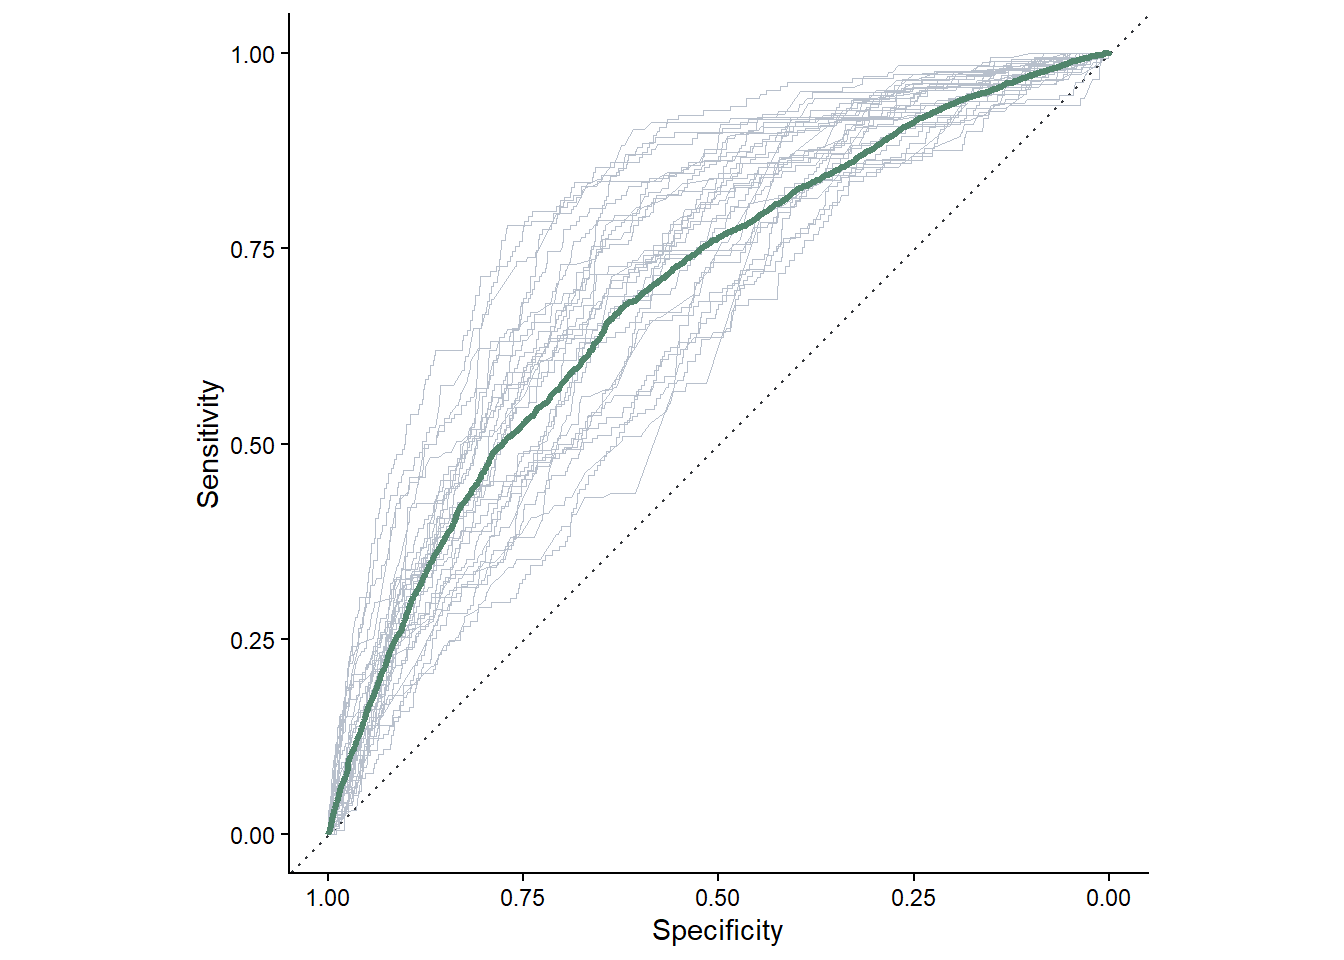

In [ ]:

roc_folds <- probs |>
  mutate(label = factor(label, levels = c("lapse", "no lapse"))) |> 
  nest(.by = outer_split_num, .key = "probs") |>
  mutate(roc = map(probs, \(probs) roc_curve(probs, prob_raw,
                                             truth = label)))

roc_data <- probs |> 
  mutate(label = factor(label, levels = c("lapse", "no lapse"))) |> 
  roc_curve(prob_raw, truth = label)

fig_roc_folds <- roc_data |>   # plot region from full concatenated data
  ggplot(aes(x = 1 - specificity, y = sensitivity)) +
  geom_abline(slope = 1, intercept = 0, linetype = "dotted", color = "#35383d") +
  coord_fixed(xlim = c(0, 1), ylim = c(0, 1)) +
  labs(x = "Specificity",
       y = "Sensitivity") +
  scale_x_continuous(breaks = seq(0,1,.25),
    labels = sprintf("%.2f", seq(1,0,-.25))) +
  theme(axis.title.x=element_blank(),
        axis.text.x=element_blank(),
        axis.ticks.x=element_blank())

for (i in 1:nrow(roc_folds)) {
  fig_roc_folds <- fig_roc_folds +
     geom_path(data = roc_folds$roc[[i]],
               mapping = aes(x = 1 - specificity, y = sensitivity),
               color = "#b8c0cc",
               linewidth = .1)
}

roc_data_smooth <- roc_data |> mutate(sensitivity = round(sensitivity, 4),
                                      specificity = round(specificity, 4)) |>
  group_by(sensitivity, specificity) |>
  summarise(.threshold = mean(.threshold))


Plot histogram of 30 held out auROCs.

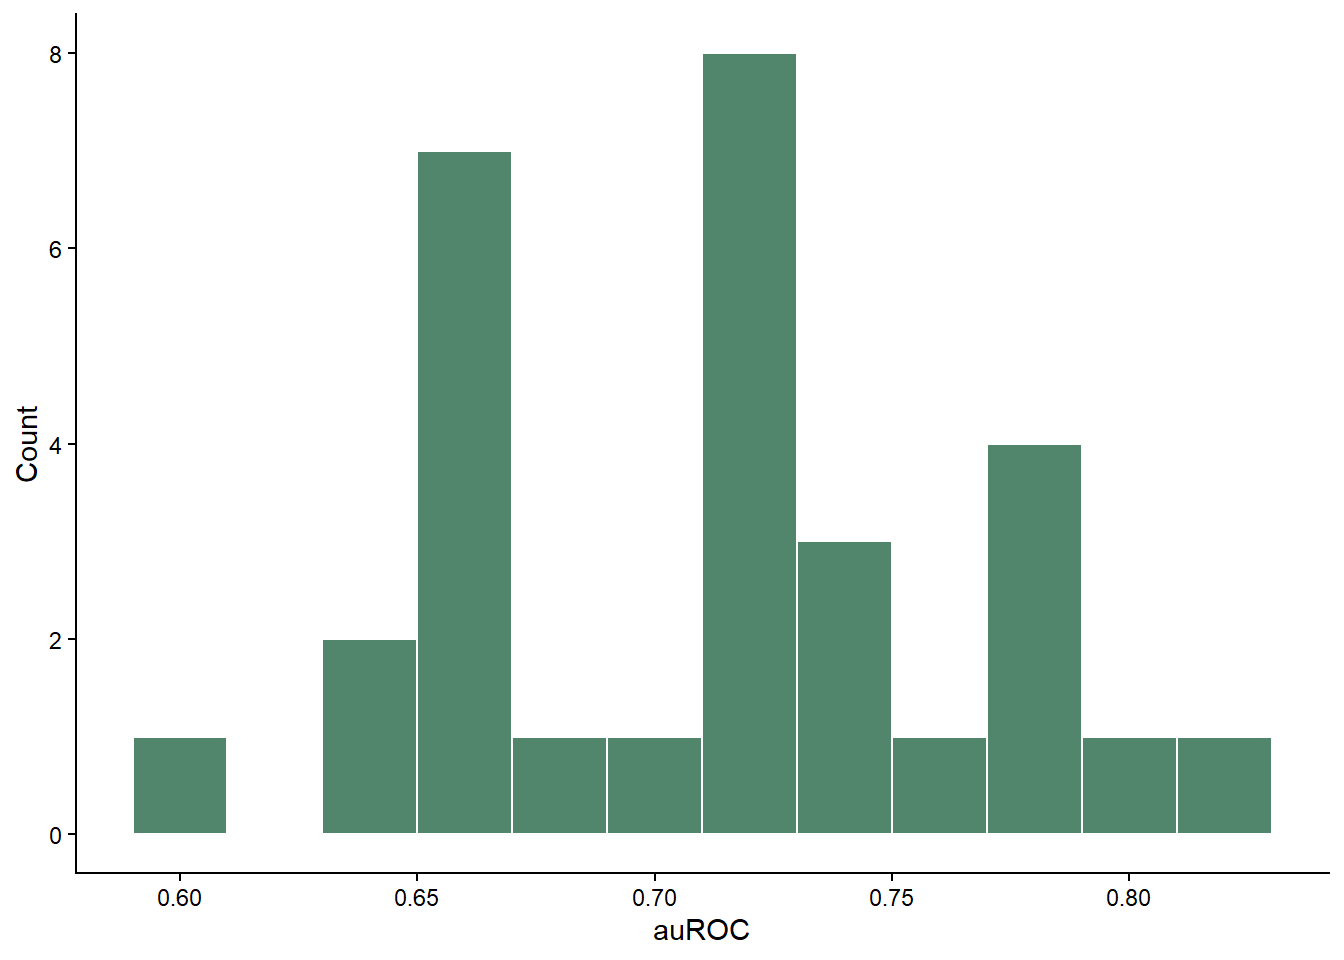

In [ ]:

auroc_summary <- probs |>
  mutate(label = factor(label, levels = c("lapse", "no lapse"))) |>
  group_by(outer_split_num) |>
  roc_auc(truth = label, prob_raw) |>
  ungroup()

auroc_summary |>
  ggplot(aes(x = .estimate)) +
  geom_histogram(binwidth = .02, color = "white", fill = "#51856c") +
  theme_classic() +
  labs(x = "auROC",
       y = "Count")


## Fairness - auROC

In [ ]:
fig_pp_auroc <- pp_dem_auroc |>
  mutate(status = if_else(model == "Male" |
                          model == "White/Caucasian" |
                          model == "Above 2018 Poverty Line" |
                          model == "Younger than 55" |
                          model == "College or more",
                          "Privileged", "Unprivileged"),
         status = factor(status, levels = c("Unprivileged", "Privileged")),
         category = case_when(model %in% c("Male", "Female") ~ "Sex",
                              model %in% c("White/Caucasian",
                                           "Non-White and/or Hispanic")
                              ~ "Race/Ethnicity",
                              model %in% c("Above 2018 Poverty Line",
                                           "Below 2018 Poverty Line")
                                ~ "Income",
                              model %in% c("Younger than 55", "Older than 55")
                              ~ "Age",
                              model %in% c("College or more", "Less than college")
                              ~ "Educational attainment")) |>
  arrange(category, status) |> 
  mutate(model = factor(model, levels = unique(model))) |> 
  ggplot(aes(x = model, y = pp_median, color = status)) +
    geom_point(aes(y = pp_median), size = 2, shape = 18) +
    geom_errorbar(aes(ymin = pp_lower, ymax = pp_upper), width = .2) +
  facet_grid(~ category,
             scales = "free_x",
space = "free_x") +
ylab("median auROC") +
    xlab(NULL) +
  ggtitle("Figure A") +
    scale_color_manual(values = c("#404E5C", "#CF1259"), guide = "none") +
    theme_classic() +
  theme(
  axis.text.x = element_text(
    angle = -45,
    hjust = 0,
    vjust = 1
  )
)


In [ ]:
fig_contrast_auroc <- contrast_dem_auroc |> 
   ggplot(aes(x = contrast, color = contrast)) +
    geom_point(aes(y = median), size = 2, shape = 18) +
    geom_errorbar(aes(ymin = lower, ymax = upper), width = .2) +
    ylab("Median auROC Difference") +
    xlab(NULL) +
    ggtitle("Figure B") +
    geom_hline(yintercept = 0.00, linetype = "dashed") +
    scale_color_manual(values = c("#404E5C", "#4F6272", "#B7C3F3", "#DD7596", "#CF1259"),name = "Contrast") +
    theme_classic() +
    theme(axis.text.x = element_blank(), axis.ticks.x = element_blank(),
          legend.position = "top", legend.direction = "vertical")


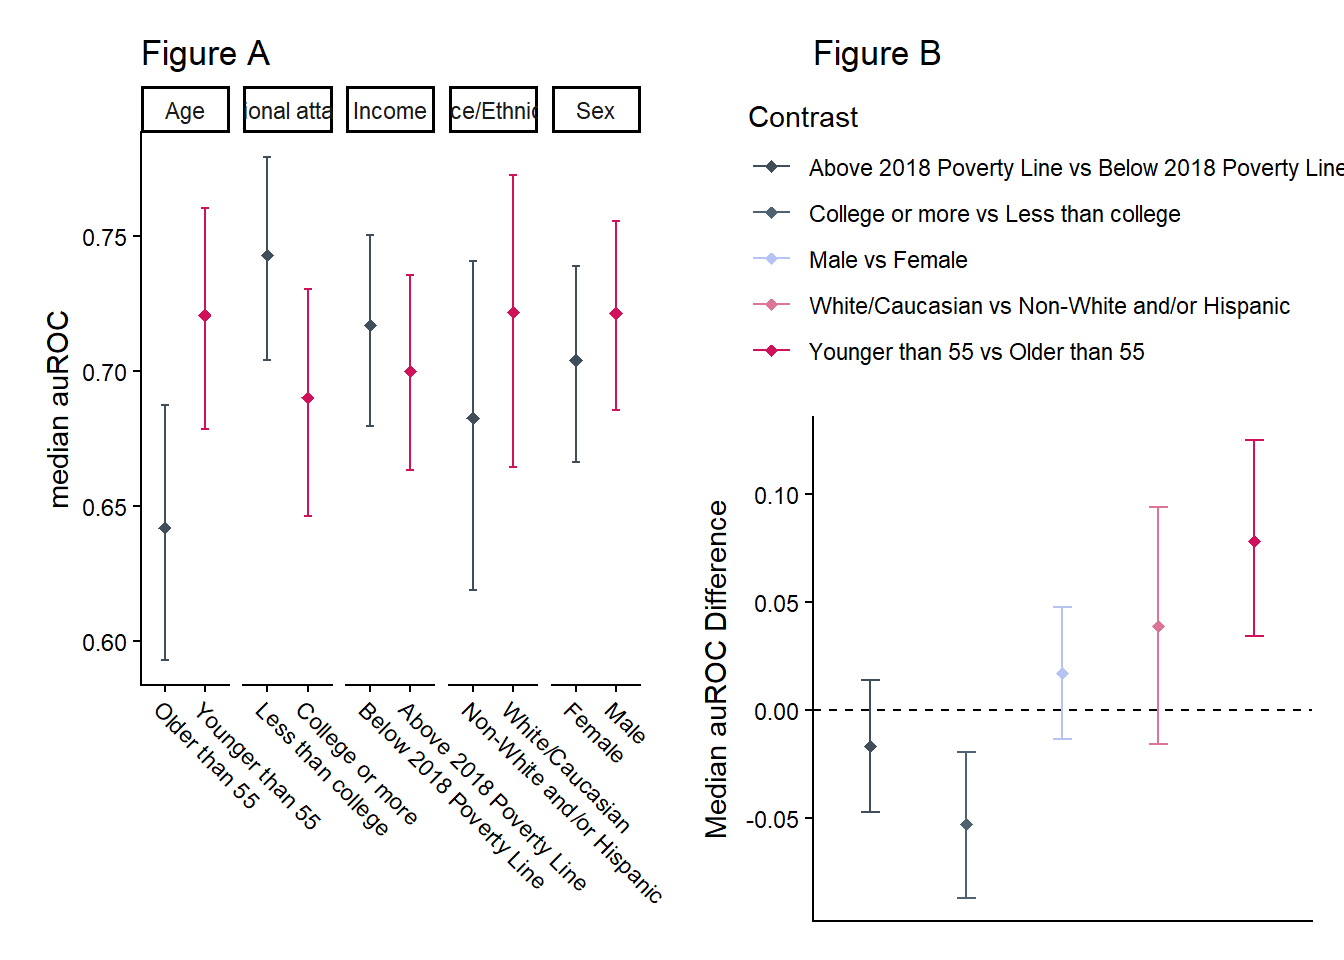

In [ ]:

cowplot::plot_grid(fig_pp_auroc, fig_contrast_auroc, align="v", axis = "l", scale = 0.95)


## Fairness - LL

In [ ]:
fig_pp_ll <- pp_dem_ll |>
  mutate(status = if_else(model == "Male" |
                          model == "White/Caucasian" |
                          model == "Above 2018 Poverty Line" |
                          model == "Younger than 55" |
                          model == "College or more",
                          "Privileged", "Unprivileged"),
         status = factor(status, levels = c("Unprivileged", "Privileged")),
         category = case_when(model %in% c("Male", "Female") ~ "Sex",
                              model %in% c("White/Caucasian",
                                           "Non-White and/or Hispanic")
                              ~ "Race/Ethnicity",
                              model %in% c("Above 2018 Poverty Line",
                                           "Below 2018 Poverty Line")
                                ~ "Income",
                              model %in% c("Younger than 55", "Older than 55")
                              ~ "Age",
                              model %in% c("College or more", "Less than college")
                              ~ "Educational attainment")) |>
  arrange(category, status) |> 
  mutate(model = factor(model, levels = unique(model))) |> 
  ggplot(aes(x = model, y = pp_median, color = status)) +
    geom_point(aes(y = pp_median), size = 2, shape = 18) +
    geom_errorbar(aes(ymin = pp_lower, ymax = pp_upper), width = .2) +
  facet_grid(~ category,
             scales = "free_x",
space = "free_x") +
ylab("median mean Log Loss") +
    xlab(NULL) +
  ggtitle("Figure A") +
    scale_color_manual(values = c("#404E5C", "#CF1259"), guide = "none") +
    theme_classic() +
  theme(
  axis.text.x = element_text(
    angle = -45,
    hjust = 0,
    vjust = 1
  )
)


In [ ]:
fig_contrast_ll <- contrast_dem_ll |> 
   ggplot(aes(x = contrast, color = contrast)) +
    geom_point(aes(y = median), size = 2, shape = 18) +
    geom_errorbar(aes(ymin = lower, ymax = upper), width = .2) +
    ylab("Median mean Log Loss Difference") +
    xlab(NULL) +
    ggtitle("Figure B") +
    geom_hline(yintercept = 0.00, linetype = "dashed") +
    scale_color_manual(values = c("#404E5C", "#4F6272", "#B7C3F3", "#DD7596", "#CF1259"),name = "Contrast") +
    theme_classic() +
    theme(axis.text.x = element_blank(), axis.ticks.x = element_blank(),
          legend.position = "top", legend.direction = "vertical")


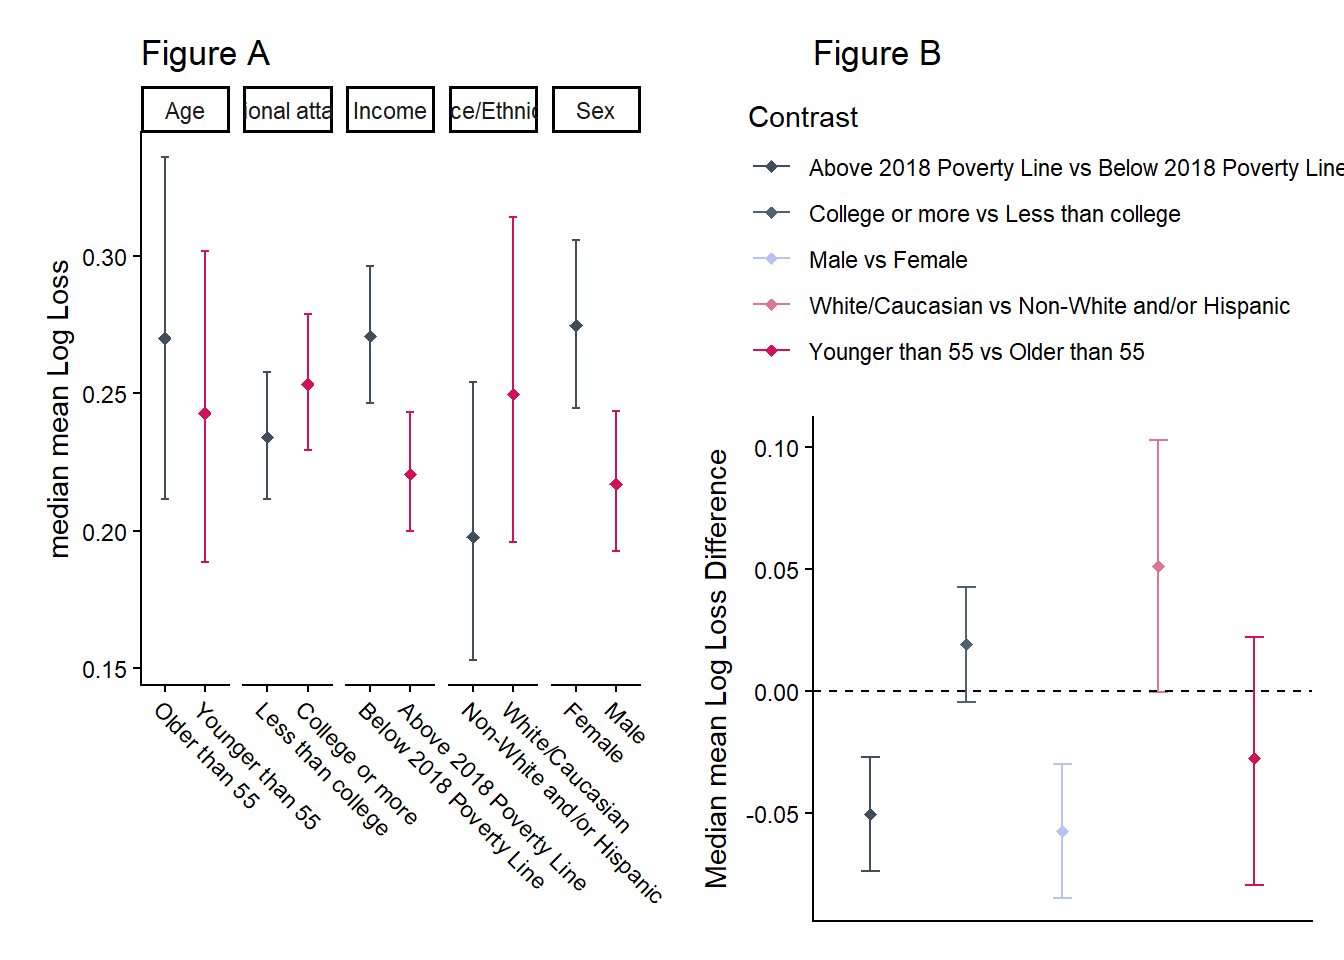

In [ ]:

cowplot::plot_grid(fig_pp_ll, fig_contrast_ll, align="v", axis = "l", scale = 0.95)


## Calibration - collapsed and grouped by fold

In [ ]:
bin_width = 0.10
cal_raw <- probs |>
  mutate(
    prob = prob_raw,
    bins = cut(prob, breaks = seq(0, 1, bin_width)),
    lapse = if_else(label == "lapse", 1, 0),
    probs = "raw"
  )


Collapsed

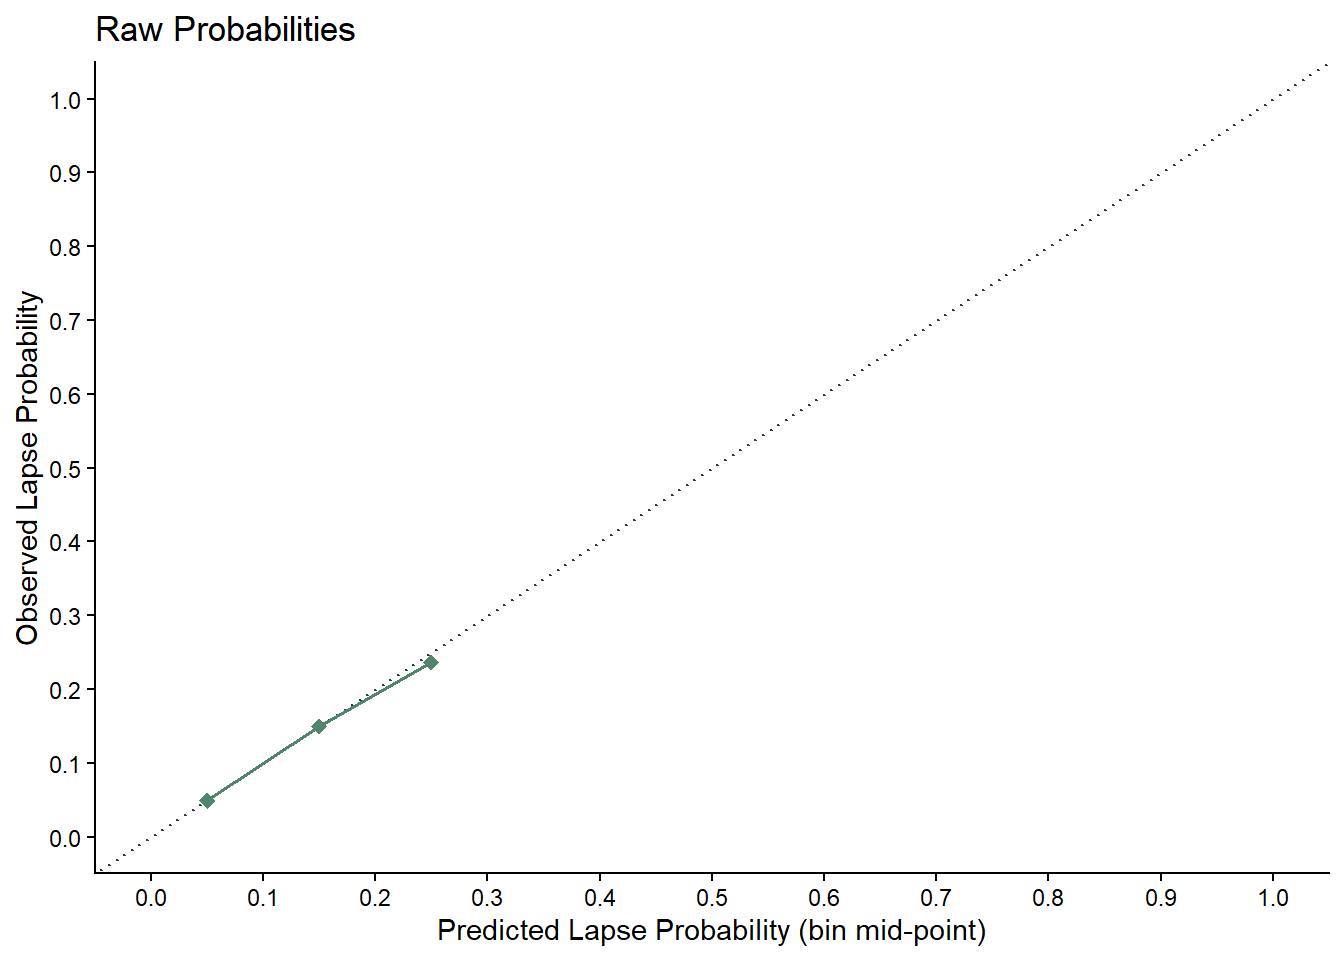

In [ ]:

cal_raw |> 
  group_by(bins, probs)  |>
  summarize(mean_lapse = mean(lapse),
            n = n(),
            .groups = "drop") |>
  filter(n >= 50) |> 
  mutate(bins = as.numeric(bins),
         midpoints = bin_width/2 + bin_width * (bins - 1))  |> 
  ggplot(data = _, aes(x = midpoints, y = mean_lapse)) +
    geom_abline(slope = 1, intercept = 0, linetype = "dotted", color = "#35383d") +
    geom_line(color = "#51856c", linewidth = .6) +
    geom_point(color = "#51856c", shape = 18, size = 2.5) +
    labs(x = "Predicted Lapse Probability (bin mid-point)",
         y = "Observed Lapse Probability",
         title = "Raw Probabilities") +
    scale_x_continuous(breaks = seq(0, 1, bin_width),
                       limits = c(0, 1)) +
    scale_y_continuous(breaks = seq(0, 1, bin_width),
                       limits = c(0, 1)) +
  theme_classic()


Grouped by fold

In [ ]:
prob_grouped_plot <- cal_raw |> 
  group_by(outer_split_num, bins, probs)  |>
  summarize(mean_lapse = mean(lapse),
            n = n(),
            .groups = "drop") |>
  filter(n >= 50) |> 
  mutate(bins = as.numeric(bins),
         midpoints = bin_width/2 + bin_width * (bins - 1))  |> 
  ggplot(data = _, aes(x = midpoints, y = mean_lapse)) +
    geom_abline(slope = 1, intercept = 0, linetype = "dotted", color = "#35383d") +
    geom_line(color = "#51856c", linewidth = .6) +
    geom_point(color = "#51856c", shape = 18, size = 2.5) +
    labs(x = "Predicted Lapse Probability (bin mid-point)",
         y = "Observed Lapse Probability",
         title = "Figure A. Raw Probabilities by Fold") +
    scale_x_continuous(breaks = seq(0, 1, bin_width),
                       limits = c(0, 1)) +
    scale_y_continuous(breaks = seq(0, 1, bin_width),
                       limits = c(0, 1)) +
  facet_wrap(~ outer_split_num) +
  theme_classic() +
  theme(
  axis.text.x = element_text(
    angle = -40,
    hjust = 0,
    vjust = 1,
    size = 5
  ),
  axis.text.y = element_text(size = 5)
)

prob_grouped_hist <- probs |> 
  ggplot(aes(x = prob_raw)) +
    geom_histogram(binwidth = .03, fill = "#51856c", color = "white") +
    labs(title = "Figure B. Histogram of Raw Probabilities by Fold",
         x = "Raw Probabilities", y = "Count") + 
    scale_x_continuous(breaks = seq(0, 1, .25)) +
    coord_cartesian(xlim = c(0, 1)) +
    scale_y_continuous(expand = expansion(mult = c(0, 0))) + # sit flush against x-axis
    facet_wrap(~ outer_split_num) +
  theme_classic() +
  theme(
  axis.text.x = element_text(
    angle = -40,
    hjust = 0,
    vjust = 1
  )
)


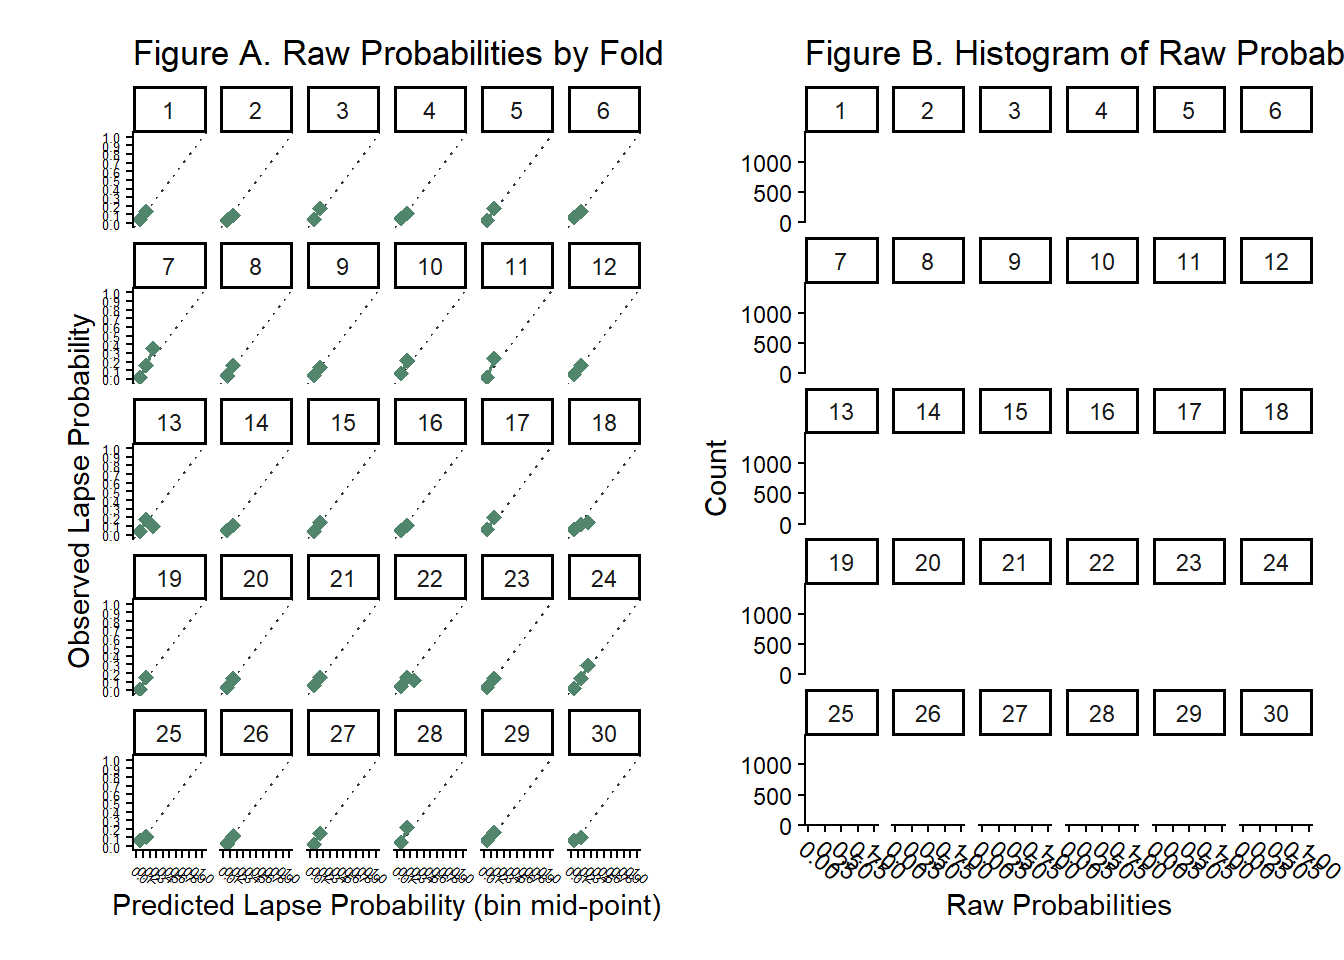

In [ ]:

cowplot::plot_grid(prob_grouped_plot, prob_grouped_hist, align="v", axis = "l", scale = 0.95)


## Shapley

In [ ]:
shap_levels <- shaps |> 
  group_by(variable_grp) |>
  summarize(mean_value = mean(abs(value)), .groups = "drop") |> 
  arrange(desc(mean_value)) |> 
  slice_head(n = 20) |> 
  arrange(mean_value) |> 
  pull(variable_grp)


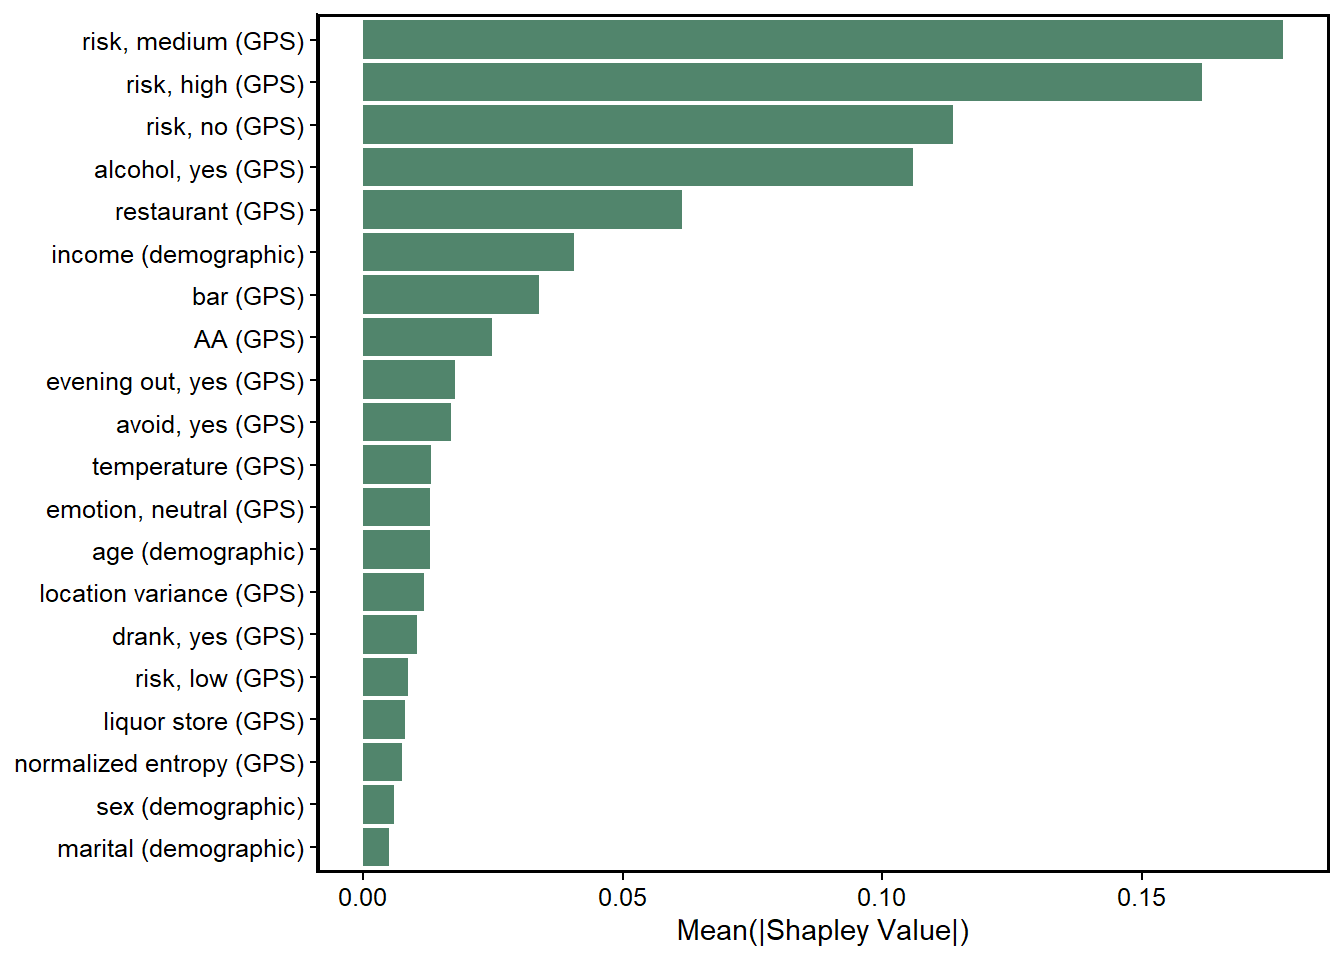

In [ ]:

shaps |>
  group_by(variable_grp) |>
  summarize(mean_value = mean(abs(value)), .groups = "drop") |> 
  filter(variable_grp %in% shap_levels) |> 
  mutate(variable_grp = factor(variable_grp, levels = shap_levels)) |> 
  ggplot(mapping = aes(x = variable_grp, y = mean_value)) +
  geom_bar(fill = "#51856c", 
           stat = "identity", position = "dodge") +
  labs(y = "Mean(|Shapley Value|)",
       x = NULL,
       fill = NULL) +
  theme_classic() +
  theme(axis.text=element_text(size=9.5),
        legend.key.size = unit(0.25, "cm"),
        panel.border = element_rect(colour = "black", fill = NA, linewidth = 1),
        legend.position = "right") +
  coord_flip()
